# Medium Small Circle Net VisualTCAV analysis

In [1]:
import sys, os, csv
import numpy as np
from pathlib import Path
from itertools import combinations

import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms

PROJECT_ROOT = Path(os.path.abspath(''))
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

from model.model_dylan import FlexibleTNet
from VisualTCAV_pytorch import Model, LocalVisualTCAV, GlobalVisualTCAV


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Project root: {PROJECT_ROOT}')
print(f'Device: {DEVICE}')

METHOD_CAV = "classifier"
CONCEPTS = ['circle_full', 'cross_full', 'square_full', 'circle_half_top', 'square_corner_bl', 'cross_arm_right']
LAYERS = []

/home/dlc/VisualTCAV/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: /home/dlc/VisualTCAV
Device: cuda


In [2]:
STAGES = [
    {"conv": [8], "fc": [32], "name": "Stage 1"},
    {"conv": [16, 32], "fc": [64], "name": "Stage 2"},
    {"conv": [16, 32, 64], "fc": [128, 64], "name": "Stage 3"},
    {"conv": [25, 35, 50], "fc": [256, 128], "name": "Stage 4"},
    {"conv": [25, 35, 50, 75], "fc": [500, 250], "name": "Stage 5"},
    {"conv": [25, 35, 50, 75, 125], "fc": [500, 250, 50], "name": "Stage 6"},
]

def find_matching_stage(state_dict):
    conv_indices = set()
    for key in state_dict.keys():
        if "conv_layers" in key:
            parts = key.split('.')
            conv_indices.add(int(parts[1]))
    num_conv_layers = len(conv_indices)

    fc0_weight = state_dict.get("fc_layers.0.0.weight")
    in_features = fc0_weight.shape[1] if fc0_weight is not None else None

    for stage in STAGES:
        if len(stage["conv"]) == num_conv_layers:
            last_conv_key = f"conv_layers.{num_conv_layers-1}.0.weight"
            if state_dict[last_conv_key].shape[0] == stage["conv"][-1]:
                return stage
                
    raise ValueError("Could not find a matching stage configuration for this weight file.")

def load_flexible_model(weight_path, device='cpu'):
    state_dict = torch.load(weight_path, map_location=device, weights_only=True)
    config = find_matching_stage(state_dict)
    print(f"-> Detected: {config['name']}")

    model = FlexibleTNet(
        num_channels=1,
        num_classes=1,
        conv_channels=config["conv"],
        fc_layers=config["fc"],
        size_img=128,
        do_sigmoid=True
    )

    model.load_state_dict(state_dict)
    model.to(device).eval()
    return model

weights_dir = 'weights_circle/'
filename = 'circle_medium_small.pth'

path = os.path.join(weights_dir, filename)

nn_model = load_flexible_model(path)


-> Detected: Stage 3


In [3]:

def preprocess_grayscale(imgs):
    return imgs.astype(np.float32) / 255.0

vtcav_model = Model(
    model_name='FlexNet_CircleMediumSmall',
    graph_path_filename=nn_model,           
    label_path_filename=['Circle present', 'Circle absent'],  
    preprocessing_function=preprocess_grayscale,
    binary_classification=True,
    max_examples=500,
    image_shape=[128, 128, 1],              
)


print(f'Model: {vtcav_model.model_name}')
print(f'Image shape: {vtcav_model.image_shape}')
print(f'Binary: {vtcav_model.binary_classification}')

Model: FlexNet_CircleMediumSmall
Image shape: [128, 128, 1]
Binary: True


In [4]:
CONCEPTS_DIR = str(PROJECT_ROOT / 'data' / 'concepts')
TEST_IMAGES_DIR = str(PROJECT_ROOT / 'data' / 'aixi_shape' / 'val')

print(f'Concepts dir: {CONCEPTS_DIR}')
print(f'Test images dir: {TEST_IMAGES_DIR}')
print(f'Concept folders: {sorted(os.listdir(CONCEPTS_DIR))}')

Concepts dir: /home/dlc/VisualTCAV/data/concepts
Test images dir: /home/dlc/VisualTCAV/data/aixi_shape/val
Concept folders: ['.DS_Store', '__MACOSX', 'blue', 'blue.zip', 'braided', 'chequered', 'circle_full', 'circle_half_bottom', 'circle_half_left', 'circle_half_right', 'circle_half_top', 'circle_quarter_bl', 'circle_quarter_br', 'circle_quarter_tl', 'circle_quarter_tr', 'cross_arm_bottom', 'cross_arm_horizontal', 'cross_arm_left', 'cross_arm_right', 'cross_arm_top', 'cross_arm_vertical', 'cross_full', 'dotted', 'forest_floor', 'forest_floor.zip', 'frekeled', 'random_0', 'random_1', 'random_2', 'random_3', 'random_pool', 'random_pool_2', 'random_pool_3', 'random_pool_4', 'spiralled', 'square_corner_bl', 'square_corner_br', 'square_corner_tl', 'square_corner_tr', 'square_edge_bottom', 'square_edge_left', 'square_edge_right', 'square_edge_top', 'square_full', 'square_half_bottom', 'square_half_left', 'square_half_right', 'square_half_top', 'stripped']


Loaded metadata for indices: 1 and 120


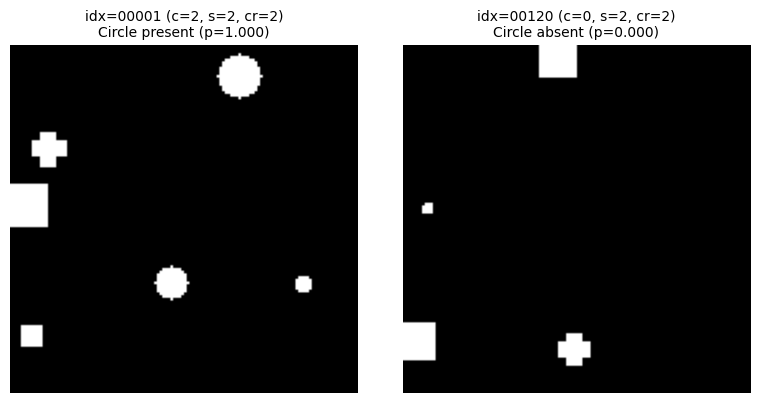

Image 1: 00001.png
Image 2: 00120.png


In [5]:


TARGET_IDX_WITH = 1   
TARGET_IDX_WITHOUT = 120

val_csv = PROJECT_ROOT / 'data' / 'aixi_shape' / 'val' / 'dades.csv'
val_dir = PROJECT_ROOT / 'data' / 'aixi_shape' / 'val'

with open(val_csv) as f:
    rows = list(csv.DictReader(f, delimiter=';'))


def get_metadata_for_idx(target_idx, csv_rows):
    for r in csv_rows:
        if int(r['']) == target_idx:
            return (target_idx, int(r['c']), int(r['s']), int(r['cr']))
    raise ValueError(f"Index {target_idx} not found in CSV.")


img_with = get_metadata_for_idx(TARGET_IDX_WITH, rows)
img_without = get_metadata_for_idx(TARGET_IDX_WITHOUT, rows)

print(f"Loaded metadata for indices: {img_with[0]} and {img_without[0]}")


img_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

nn_model.to(DEVICE)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, (idx, c, s, cr) in zip(axes, [img_with, img_without]):
    img = Image.open(val_dir / f'{idx:05d}.png')
    
    t = img_transform(img.convert('L')).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        p = nn_model(t).item()
        
    ax.imshow(np.array(img), cmap='gray')
    label = 'Circle present' if p > 0.5 else 'Circle absent'
    ax.set_title(f'idx={idx:05d} (c={c}, s={s}, cr={cr})\n{label} (p={p:.3f})', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f'Image 1: {img_with[0]:05d}.png')
print(f'Image 2: {img_without[0]:05d}.png')

TCAV device: cuda
Circle present: torch.Size([200, 1, 128, 128])
Circle absent:  torch.Size([200, 1, 128, 128])

[1] Running TCAV: circle_full vs randoms...


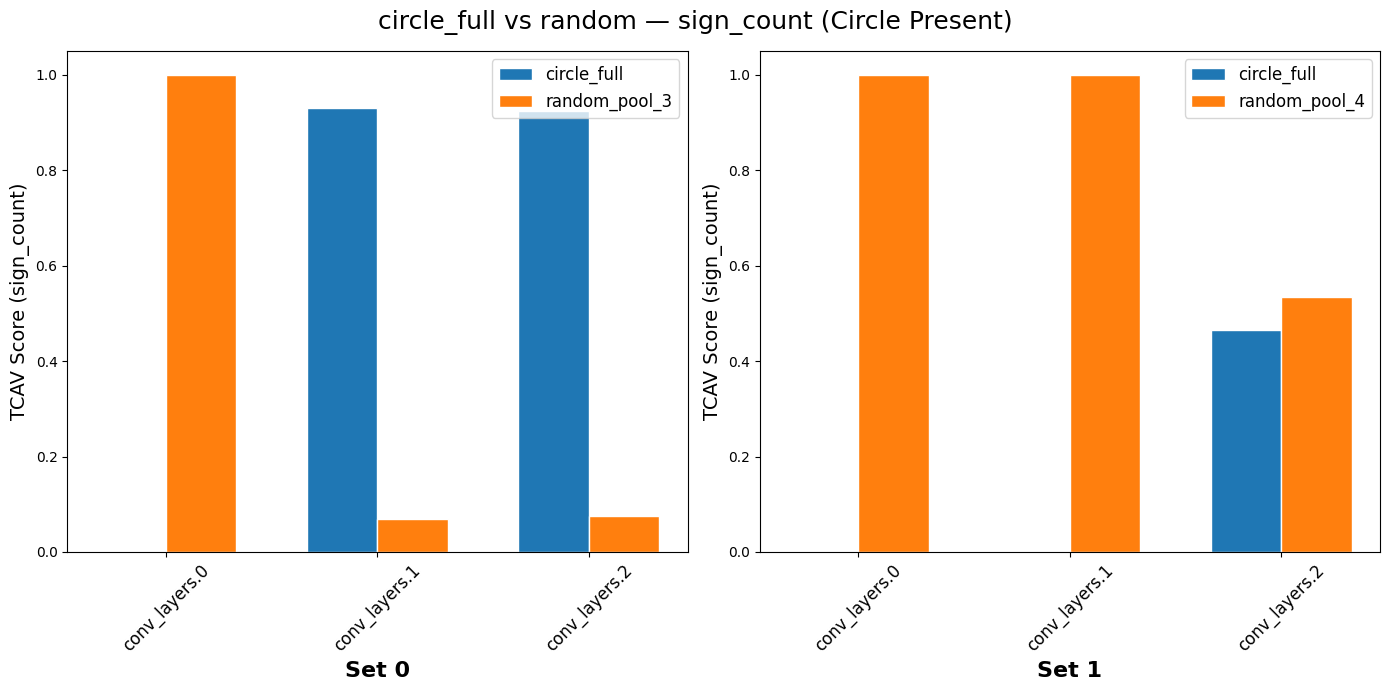

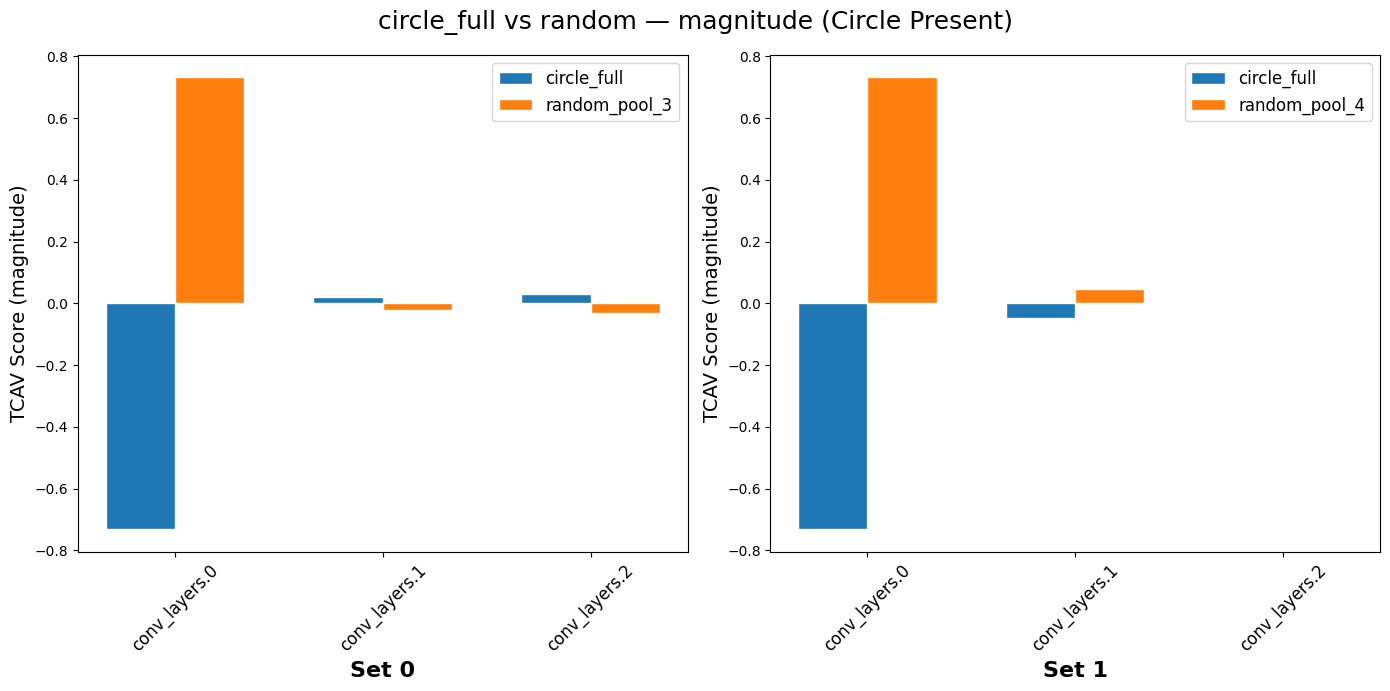


[2] Running TCAV: all concepts (Circle Present)...


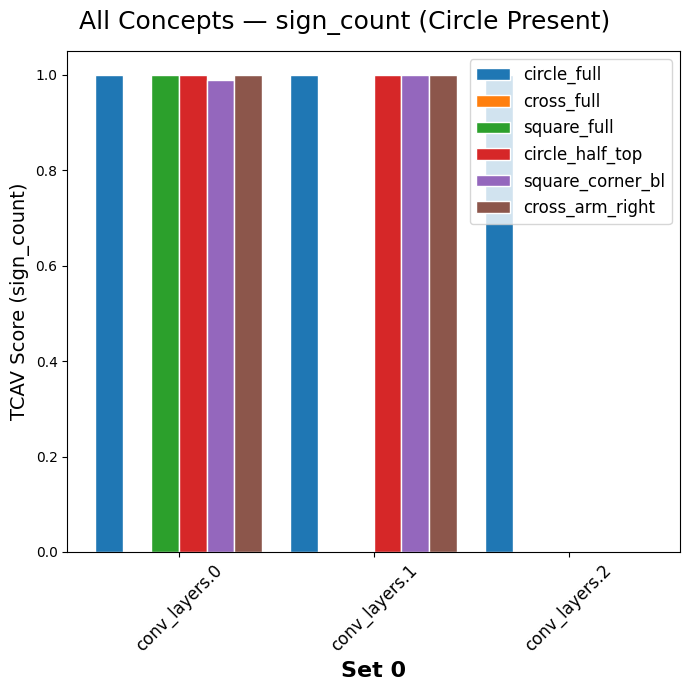

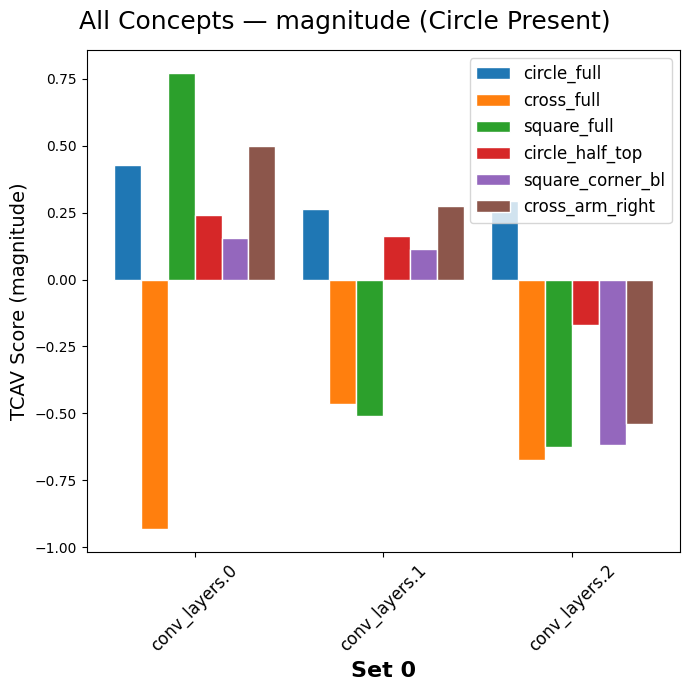


[3] Running TCAV: all concepts (Circle Absent)...


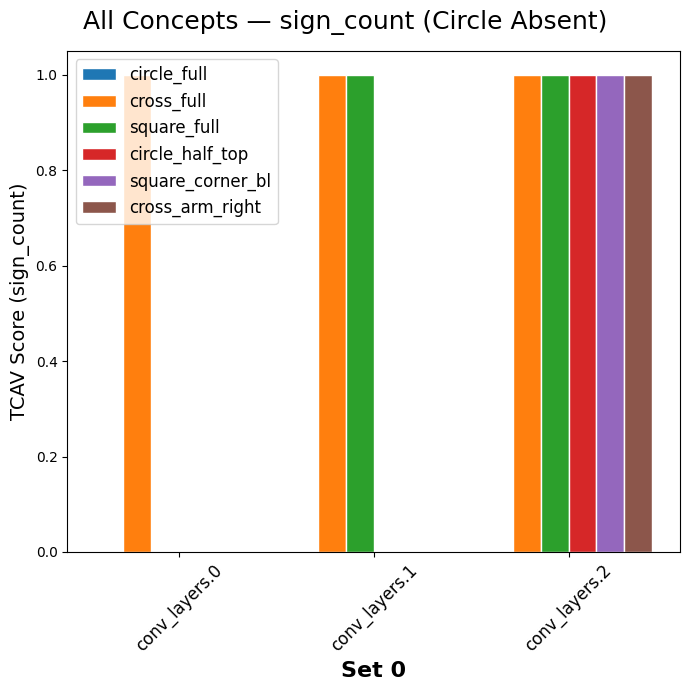

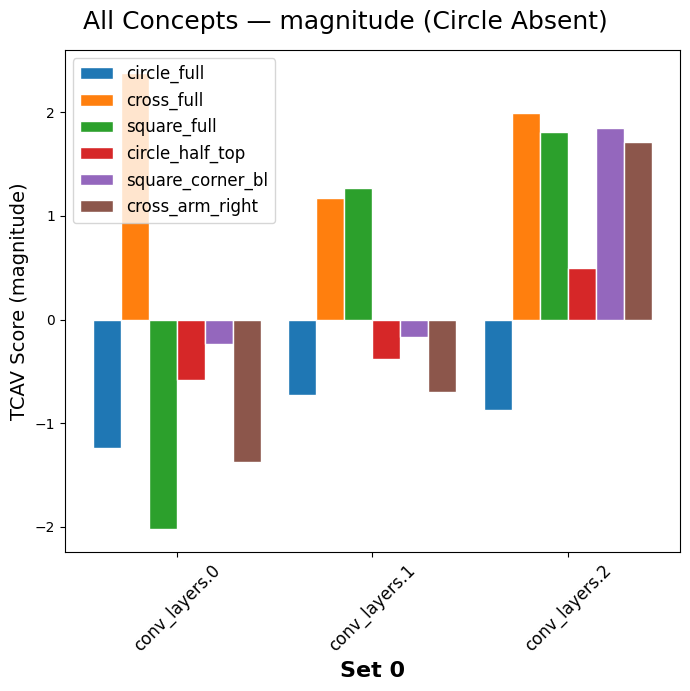

12220

In [6]:
##############################################
# Captum TCAV — Circle Detection Model
##############################################
#
# ┌─────────────────────────────────────────────────────────────────┐
# │ PRE-SIGMOID LOGIT APPROACH (faithful to Kim et al. 2018)       │
# │                                                                 │
# │ TCAV computes: S_C(x) = ∇_h f_k(x) · v_C                     │
# │ The directional derivative of the model output w.r.t. layer    │
# │ activations, dotted with the Concept Activation Vector.        │
# │                                                                 │
# │ Kim et al. use pre-softmax logits (not probabilities) so the   │
# │ gradient doesn't suffer from output saturation. We follow the  │
# │ same approach: the wrapper outputs pre-sigmoid logits as a     │
# │ 2-column tensor [-z, z], avoiding sigmoid saturation entirely. │
# │                                                                 │
# │ This means we use Captum's default LayerGradientXActivation    │
# │ (plain gradients), NOT LayerIntegratedGradients.               │
# │                                                                 │
# │ Additionally, Captum's DefaultClassifier has a device mismatch │
# │ bug on GPU (classes() returns CPU tensor, argmax returns CUDA).│
# │ We fix this with GPUClassifier below.                          │
# └─────────────────────────────────────────────────────────────────┘

import gc
import glob
import random
import numpy as np
import os
import copy
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader, TensorDataset
from PIL import Image
from torchvision import transforms
from scipy.stats import ttest_ind

from captum.concept import TCAV, Concept
from captum.concept._utils.data_iterator import dataset_to_dataloader, CustomIterableDataset
from captum.concept._utils.common import concepts_to_str
from captum.concept._utils.classifier import Classifier
from captum._utils.models.linear_model.model import SkLearnSGDClassifier

# ── GPU-safe classifier (fixes Captum's device mismatch bug) ─────────
# Captum's DefaultClassifier crashes on GPU because:
#   1. self.lm.classes() returns a CPU tensor
#   2. torch.argmax(predict, dim=1) returns a CUDA tensor
#   3. CPU tensor indexed by CUDA tensor → RuntimeError
# This classifier keeps everything on the same device.

class GPUClassifier(Classifier):
    def __init__(self):
        self.lm = SkLearnSGDClassifier(alpha=0.01, max_iter=1000, tol=1e-3)

    def train_and_eval(self, dataloader, test_split_ratio=0.33, **kwargs):
        inputs = []
        labels = []
        for inp, label in dataloader:
            inputs.append(inp)
            labels.append(label)

        all_inputs = torch.cat(inputs)
        all_labels = torch.cat(labels)
        device = all_inputs.device

        # Shuffle and split
        z_list = list(zip(all_inputs, all_labels))
        random.shuffle(z_list)
        test_size = int(test_split_ratio * len(z_list))
        z_test, z_train = z_list[:test_size], z_list[test_size:]
        x_test, y_test = zip(*z_test)
        x_train, y_train = zip(*z_train)
        x_train, x_test = torch.stack(x_train), torch.stack(x_test)
        y_train, y_test = torch.stack(y_train), torch.stack(y_test)

        self.lm.device = device
        self.lm.fit(DataLoader(TensorDataset(x_train, y_train)))

        predict = self.lm(x_test)
        # FIX: move classes() to the same device as argmax output
        classes = self.lm.classes().to(device)
        predict = classes[torch.argmax(predict, dim=1)]
        score = predict.long() == y_test.long()

        return {"accs": score.float().mean()}

    def weights(self):
        weights = self.lm.representation()
        if weights.shape[0] == 1:
            return torch.stack([-1 * weights[0], weights[0]])
        return weights

    def classes(self):
        return self.lm.classes().detach().numpy()

# ── 1. Setup ─────────────────────────────────────────────────────────

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CONCEPTS_DIR = str(PROJECT_ROOT / 'data' / 'concepts')
GLOBAL_TEST_DIR = str(PROJECT_ROOT / 'data' / 'aixi_shape' / 'val_global_test')
CIRCLE_PRESENT_IDX = 1
CIRCLE_ABSENT_IDX = 0
print(f"TCAV device: {DEVICE}")

grayscale_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

# ── 2. Pre-sigmoid logit wrapper ─────────────────────────────────────
# Captum TCAV expects [B, num_classes] output. Following Kim et al.,
# we output PRE-SIGMOID logits (not probabilities) to avoid sigmoid
# saturation killing gradients. Output: [-z, z] where z is the raw logit.

class LogitWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self._inner = model
        self.conv_layers = model.conv_layers
        self.fc_layers = model.fc_layers
        self.output = model.output

    def forward(self, x):
        x = x.to(next(self._inner.parameters()).device)
        x = self.conv_layers(x)
        x = torch.flatten(x, 1)
        x = self.fc_layers(x)
        z = self.output(x)  # raw logit, NO sigmoid
        return torch.cat([-z, z], dim=1)

tcav_model = LogitWrapper(copy.deepcopy(nn_model).to(DEVICE))
tcav_model.eval()

# ── 3. Helpers ───────────────────────────────────────────────────────

def get_tensor_from_filename(filename):
    img = Image.open(filename).convert('L')
    return grayscale_transform(img)

MAX_CONCEPT_IMAGES = 250  # Kim et al. used as few as 30; reduce further if OOM

class LimitedIterableDataset(torch.utils.data.IterableDataset):
    """Like CustomIterableDataset but limits to max_images files."""
    def __init__(self, transform_fn, path, max_images):
        self.transform_fn = transform_fn
        all_files = sorted(glob.glob(os.path.join(path, '*')))
        if max_images and len(all_files) > max_images:
            random.seed(42)
            all_files = random.sample(all_files, max_images)
        self.files = all_files

    def __iter__(self):
        for f in self.files:
            yield self.transform_fn(f)

def assemble_concept(name, id, concepts_path=CONCEPTS_DIR, max_images=MAX_CONCEPT_IMAGES):
    concept_path = os.path.join(concepts_path, name) + "/"
    if max_images:
        dataset = LimitedIterableDataset(get_tensor_from_filename, concept_path, max_images)
    else:
        dataset = CustomIterableDataset(get_tensor_from_filename, concept_path)
    concept_iter = dataset_to_dataloader(dataset)
    return Concept(id=id, name=name, data_iter=concept_iter)

def load_test_images(class_dir):
    tensors = []
    for f in sorted(glob.glob(os.path.join(class_dir, '*.png'))):
        tensors.append(get_tensor_from_filename(f))
    return torch.stack(tensors)

def format_float(f):
    return float('{:.3f}'.format(f) if abs(f) >= 0.0005 else '{:.3e}'.format(f))

def plot_tcav_scores(experimental_sets, tcav_scores, layers, title, metric='sign_count'):
    n_sets = len(experimental_sets)
    fig, ax = plt.subplots(1, n_sets, figsize=(7 * n_sets, 7))
    if n_sets == 1:
        ax = [ax]

    for idx_es, concepts in enumerate(experimental_sets):
        concepts_key = concepts_to_str(concepts)
        n_concepts = len(concepts)
        barWidth = 1 / (n_concepts + 1)

        pos = [np.arange(len(layers))]
        for i in range(1, n_concepts):
            pos.append([(x + barWidth) for x in pos[i-1]])

        for i in range(n_concepts):
            val = [format_float(scores[metric][i])
                   for _, scores in tcav_scores[concepts_key].items()]
            ax[idx_es].bar(pos[i], val, width=barWidth, edgecolor='white',
                           label=concepts[i].name)

        ax[idx_es].set_xlabel(f'Set {idx_es}', fontweight='bold', fontsize=16)
        ax[idx_es].set_xticks([r + barWidth * (n_concepts - 1) / 2 for r in range(len(layers))])
        ax[idx_es].set_xticklabels(layers, fontsize=12, rotation=45)
        ax[idx_es].legend(fontsize=12)
        if metric == 'sign_count':
            ax[idx_es].set_ylim([0, 1.05])
        ax[idx_es].set_ylabel(f'TCAV Score ({metric})', fontsize=14)

    plt.suptitle(title, fontsize=18)
    plt.tight_layout()
    plt.show()

# ── 4. Concepts ──────────────────────────────────────────────────────

circle_full   = assemble_concept("circle_full",      0)
cross_full    = assemble_concept("cross_full",        1)
square_full   = assemble_concept("square_full",       2)
circle_half   = assemble_concept("circle_half_top",   3)
square_corner = assemble_concept("square_corner_bl",  4)
cross_arm     = assemble_concept("cross_arm_right",   5)

random_0 = assemble_concept("random_0", 10)
random_1 = assemble_concept("random_1", 11)
random_2 = assemble_concept("random_pool_3", 12)
random_3 = assemble_concept("random_pool_4", 13)

# ── 5. Layers & TCAV instance ────────────────────────────────────────

layers = ['conv_layers.0', 'conv_layers.1', 'conv_layers.2']

mytcav = TCAV(
    model=tcav_model,
    layers=layers,
    model_id = "Circle_MediumSmall", 
    classifier=GPUClassifier(),
)

# ── 6. Load test images ──────────────────────────────────────────────

circle_present_tensors = load_test_images(os.path.join(GLOBAL_TEST_DIR, 'circle_present')).to(DEVICE)
circle_absent_tensors = load_test_images(os.path.join(GLOBAL_TEST_DIR, 'circle_absent')).to(DEVICE)
print(f"Circle present: {circle_present_tensors.shape}")
print(f"Circle absent:  {circle_absent_tensors.shape}")

# ── 7. Experimental sets ─────────────────────────────────────────────

experimental_sets_rand = [
    [circle_full, random_2],
    [circle_full, random_3],
]

experimental_sets_all = [
    [circle_full, cross_full, square_full, circle_half, square_corner, cross_arm],
]

# ══════════════════════════════════════════════════════════════════════
# EXPERIMENT 1: circle_full vs randoms
# ══════════════════════════════════════════════════════════════════════

print("\n[1] Running TCAV: circle_full vs randoms...")
scores_rand = mytcav.interpret(
    inputs=circle_present_tensors,
    experimental_sets=experimental_sets_rand,
    target=CIRCLE_PRESENT_IDX,
)

plot_tcav_scores(experimental_sets_rand, scores_rand, layers,
                 title='circle_full vs random — sign_count (Circle Present)')
plot_tcav_scores(experimental_sets_rand, scores_rand, layers,
                 title='circle_full vs random — magnitude (Circle Present)',
                 metric='magnitude')

# ══════════════════════════════════════════════════════════════════════
# EXPERIMENT 2: All concepts head-to-head (Circle Present)
# ══════════════════════════════════════════════════════════════════════

print("\n[2] Running TCAV: all concepts (Circle Present)...")
scores_all_present = mytcav.interpret(
    inputs=circle_present_tensors,
    experimental_sets=experimental_sets_all,
    target=CIRCLE_PRESENT_IDX,
)

plot_tcav_scores(experimental_sets_all, scores_all_present, layers,
                 title='All Concepts — sign_count (Circle Present)')
plot_tcav_scores(experimental_sets_all, scores_all_present, layers,
                 title='All Concepts — magnitude (Circle Present)',
                 metric='magnitude')

# ══════════════════════════════════════════════════════════════════════
# EXPERIMENT 3: All concepts head-to-head (Circle Absent)
# ══════════════════════════════════════════════════════════════════════

print("\n[3] Running TCAV: all concepts (Circle Absent)...")
scores_all_absent = mytcav.interpret(
    inputs=circle_absent_tensors,
    experimental_sets=experimental_sets_all,
    target=CIRCLE_ABSENT_IDX,
)

plot_tcav_scores(experimental_sets_all, scores_all_absent, layers,
                 title='All Concepts — sign_count (Circle Absent)')
plot_tcav_scores(experimental_sets_all, scores_all_absent, layers,
                 title='All Concepts — magnitude (Circle Absent)',
                 metric='magnitude')

# Free experiments 1-3
del scores_rand, scores_all_present, scores_all_absent
gc.collect()


## Amb Cercles

In [7]:
local_explainer = LocalVisualTCAV(
    test_image_filename=f'{img_with[0]:05d}.png',
    m_steps=80,
    model=vtcav_model,
    concept_images_dir=CONCEPTS_DIR,
    test_images_dir=TEST_IMAGES_DIR,
    random_images_folder='random_pool_4', # Same distribution idk
    cav_method=METHOD_CAV,
    device=DEVICE,
)

local_explainer.setConcepts(CONCEPTS)
local_explainer.setLayers(['conv_layers.0', 'conv_layers.1', 'conv_layers.2'])

predictions = local_explainer.predict(no_sort=True)
predictions.info()

print(f'\nAvailable layers: {vtcav_model.getLayerNames()}')


Model: FlexNet_CircleMediumSmall
    Image     Class name Confidence
00001.png Circle present       1.00

Available layers: ['conv_layers', 'conv_layers.0', 'conv_layers.0.0', 'conv_layers.1', 'conv_layers.1.0', 'conv_layers.2', 'conv_layers.2.0', 'fc_layers', 'fc_layers.0', 'fc_layers.0.0', 'fc_layers.1', 'fc_layers.1.0', 'output']


```
  FlexibleTNet                                                                                                                                               
  ├── conv_layers          → Sequential (the whole conv block container)                                                                                     
  │   └── 0                → Sequential (first conv block: Conv2d + ReLU + BN + MaxPool)                                                                     
  │       ├── 0            → Conv2d(1, 8, 3x3)        ← conv_layers.0.0                                                                                      
  │       ├── 1            → ReLU()
  │       ├── 2            → BatchNorm2d(8)
  │       └── 3            → MaxPool2d(2)
  ├── fc_layers            → Sequential (the whole FC block container)
  │   └── 0                → Sequential (first FC block: Linear + Dropout + ReLU)
  │       ├── 0            → Linear(32768 → 32)        ← fc_layers.0.0
  │       ├── 1            → Dropout(0.2)
  │       └── 2            → ReLU()
  ├── output               → Linear(32 → 1)
  └── final_act            → Sigmoid()
  ```
  

In [8]:
local_explainer.explain(cache_cav=False, cache_random=False)

for concept_name in local_explainer.concepts:
    for layer_name in local_explainer.layers:
        cl = local_explainer.computations[layer_name][concept_name]
        attribs = {k: v.item() if isinstance(v, torch.Tensor) else v
                   for k, v in cl.attributions.items()}
        print(f'{concept_name} @ {layer_name}: {attribs}')

Layers: 100%|██████████| 3/3 [00:02<00:00,  1.27it/s]

circle_full @ conv_layers.0: {0: 0.19680745899677277, 1: 0.06528075039386749}
circle_full @ conv_layers.1: {0: 0.17038854956626892, 1: 0.019907433539628983}
circle_full @ conv_layers.2: {0: 0.07608026266098022, 1: 0.0013252170756459236}
cross_full @ conv_layers.0: {0: 0.07164110988378525, 1: 0.021436195820569992}
cross_full @ conv_layers.1: {0: 0.044870756566524506, 1: 0.008669658564031124}
cross_full @ conv_layers.2: {0: 0.00031310145277529955, 1: 0.0008732565911486745}
square_full @ conv_layers.0: {0: 0.09219752252101898, 1: 0.05801244452595711}
square_full @ conv_layers.1: {0: 0.04308788478374481, 1: 0.007575523108243942}
square_full @ conv_layers.2: {0: 0.00028217508224770427, 1: 0.0008334239828400314}
circle_half_top @ conv_layers.0: {0: 0.09272700548171997, 1: 0.02051212638616562}
circle_half_top @ conv_layers.1: {0: 0.05830904468894005, 1: 0.006710004061460495}
circle_half_top @ conv_layers.2: {0: 0.002755087101832032, 1: 0.0017545433947816491}
square_corner_bl @ conv_layers.0: 

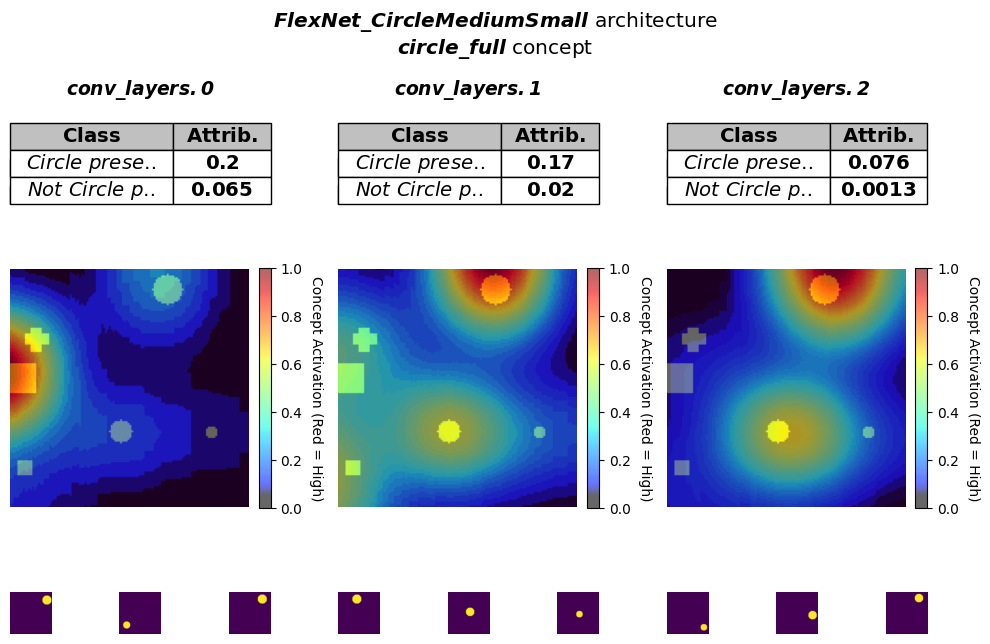

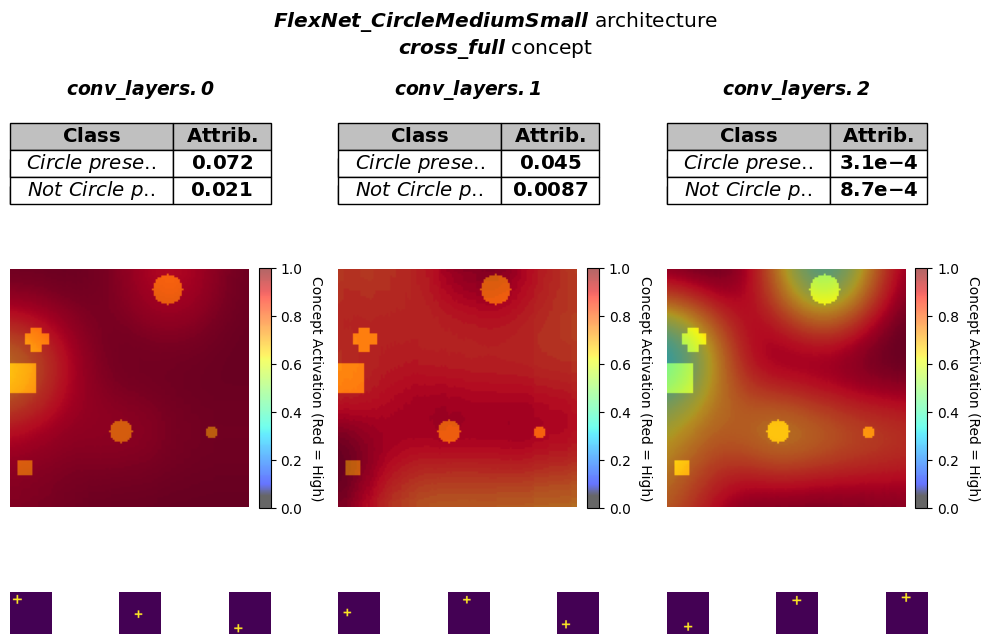

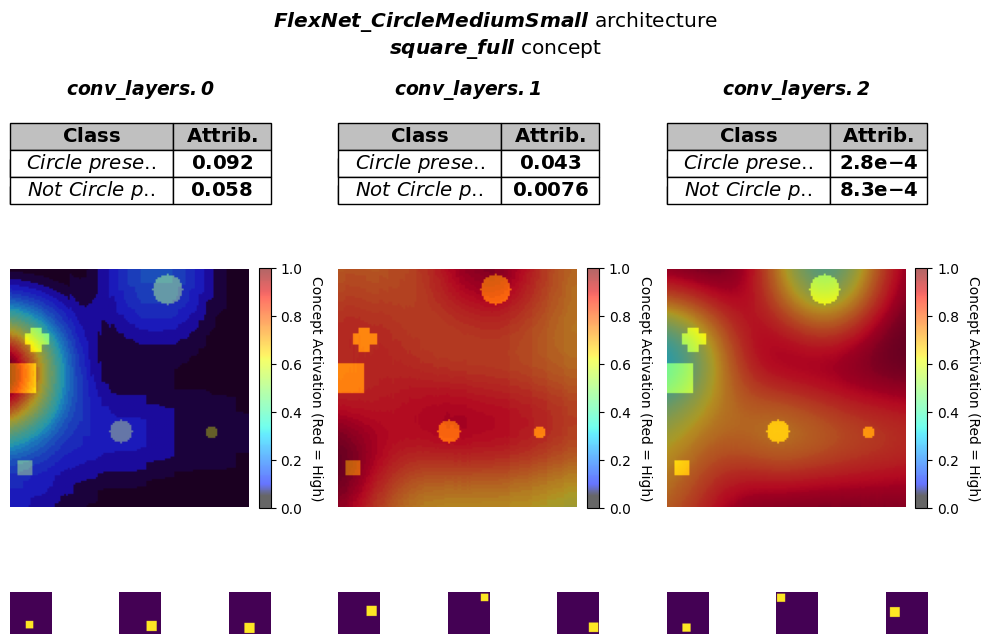

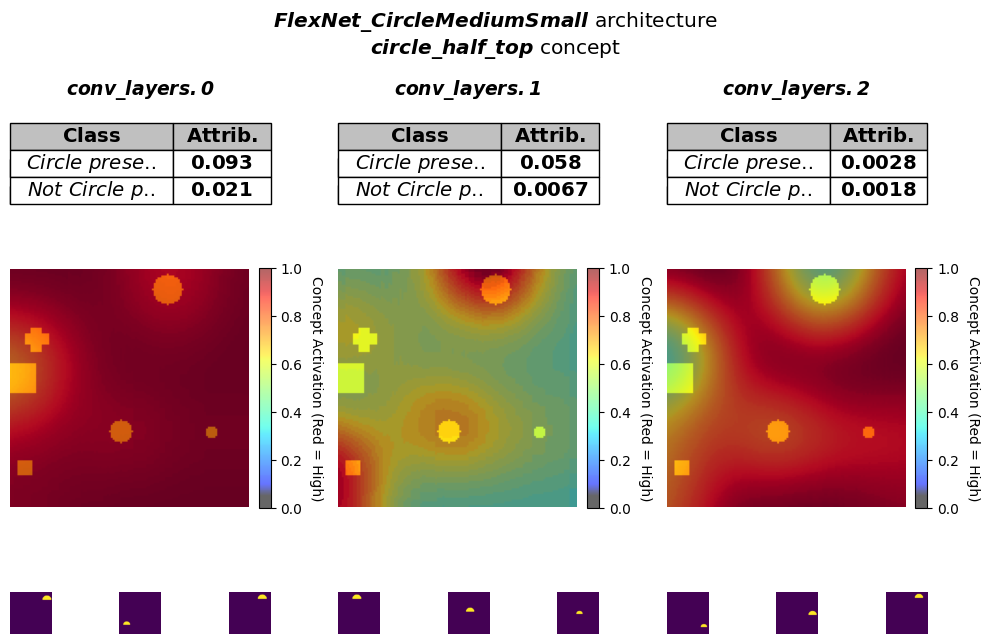

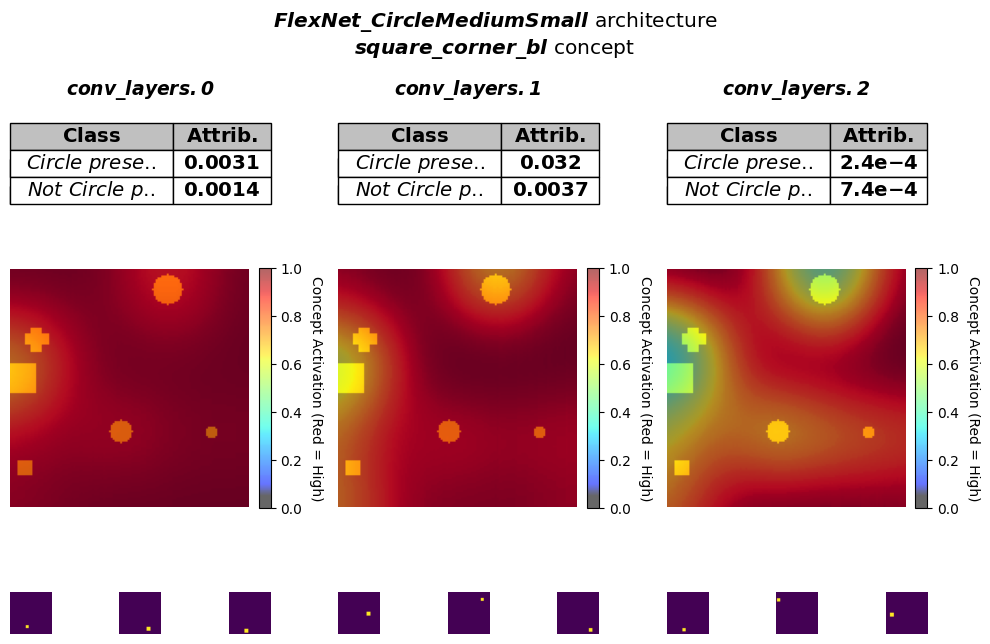

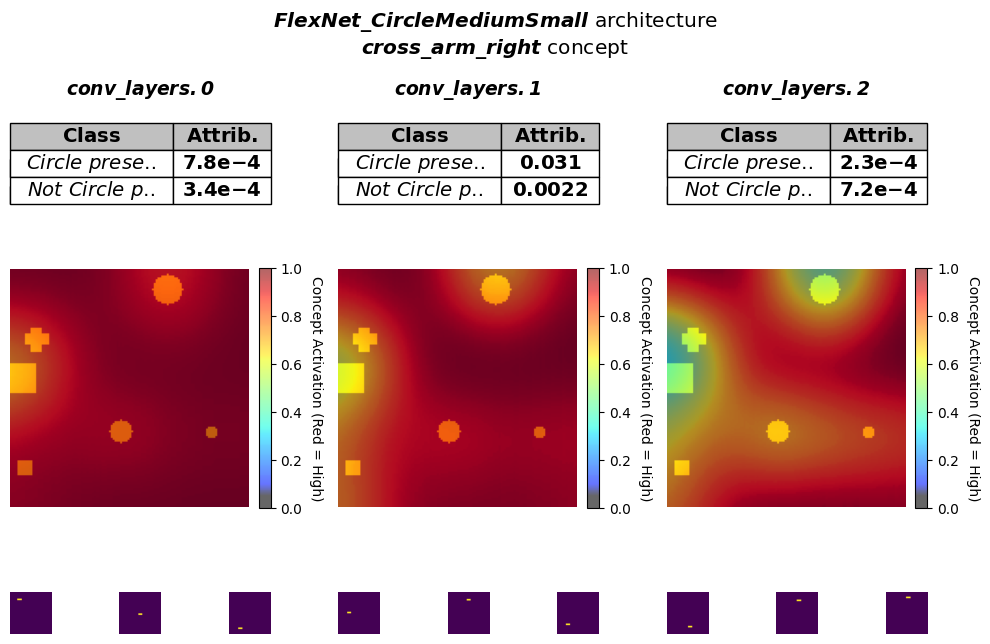

In [9]:
# Plot heatmaps
local_explainer.plot()

circle_full: norm=3.1365, emblem=(20.6738, 4.5682)
cross_full: norm=2.3588, emblem=(0.6989, 0.0000)
square_full: norm=3.4299, emblem=(12.2707, 7.0890)
circle_half_top: norm=2.5129, emblem=(0.7961, 0.0000)
square_corner_bl: norm=2.1276, emblem=(0.6461, 0.0000)
cross_arm_right: norm=1.9858, emblem=(0.6281, 0.0000)

Cosine similarities between CAV directions:
  circle_full vs cross_full: 0.7873
  circle_full vs square_full: 0.9541
  circle_full vs circle_half_top: 0.8534
  circle_full vs square_corner_bl: 0.6658
  circle_full vs cross_arm_right: 0.6031
  cross_full vs square_full: 0.7602
  cross_full vs circle_half_top: 0.9831
  cross_full vs square_corner_bl: 0.9702
  cross_full vs cross_arm_right: 0.9449
  square_full vs circle_half_top: 0.8232
  square_full vs square_corner_bl: 0.6497
  square_full vs cross_arm_right: 0.5883
  circle_half_top vs square_corner_bl: 0.9551
  circle_half_top vs cross_arm_right: 0.9277
  square_corner_bl vs cross_arm_right: 0.9955


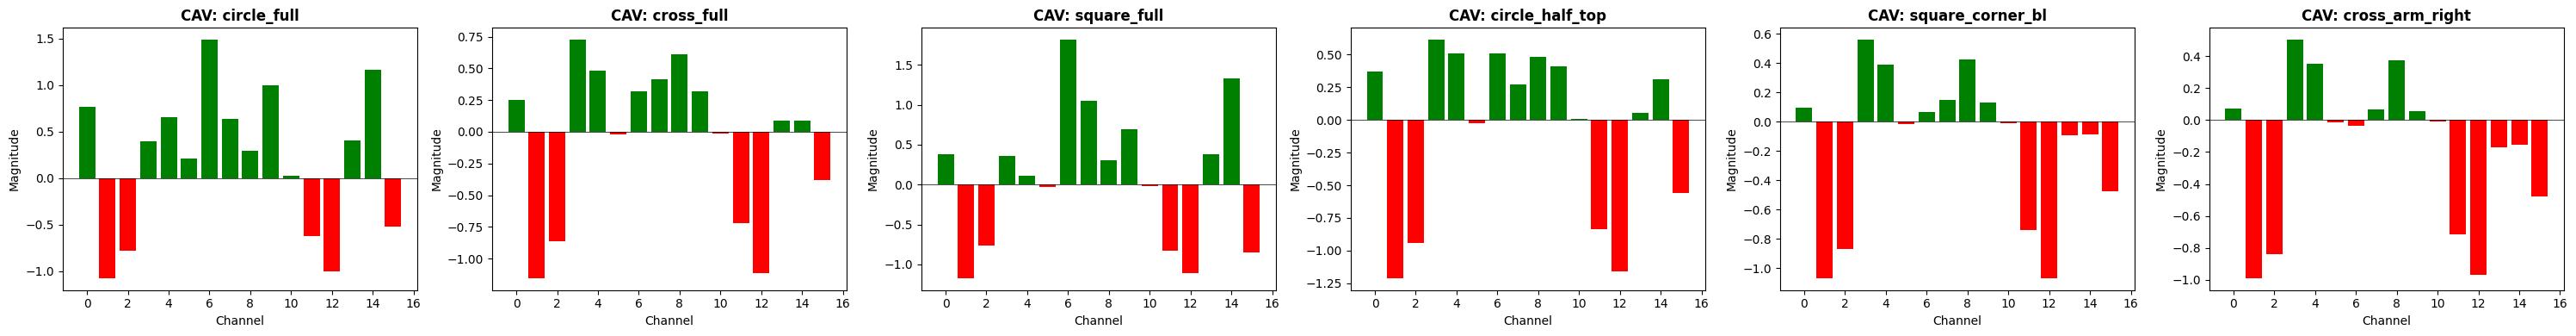

circle_full: norm=1.3878, emblem=(21.4482, 0.0265)
cross_full: norm=1.2112, emblem=(1.0904, 0.0000)
square_full: norm=1.5121, emblem=(1.1304, 0.0000)
circle_half_top: norm=1.2631, emblem=(3.9236, 0.0000)
square_corner_bl: norm=1.0929, emblem=(0.4474, 0.0000)
cross_arm_right: norm=1.0572, emblem=(0.4714, 0.0000)

Cosine similarities between CAV directions:
  circle_full vs cross_full: 0.8154
  circle_full vs square_full: 0.7809
  circle_full vs circle_half_top: 0.8837
  circle_full vs square_corner_bl: 0.6776
  circle_full vs cross_arm_right: 0.6317
  cross_full vs square_full: 0.9519
  cross_full vs circle_half_top: 0.9438
  cross_full vs square_corner_bl: 0.9262
  cross_full vs cross_arm_right: 0.8856
  square_full vs circle_half_top: 0.9012
  square_full vs square_corner_bl: 0.8519
  square_full vs cross_arm_right: 0.7931
  circle_half_top vs square_corner_bl: 0.9025
  circle_half_top vs cross_arm_right: 0.8680
  square_corner_bl vs cross_arm_right: 0.9934


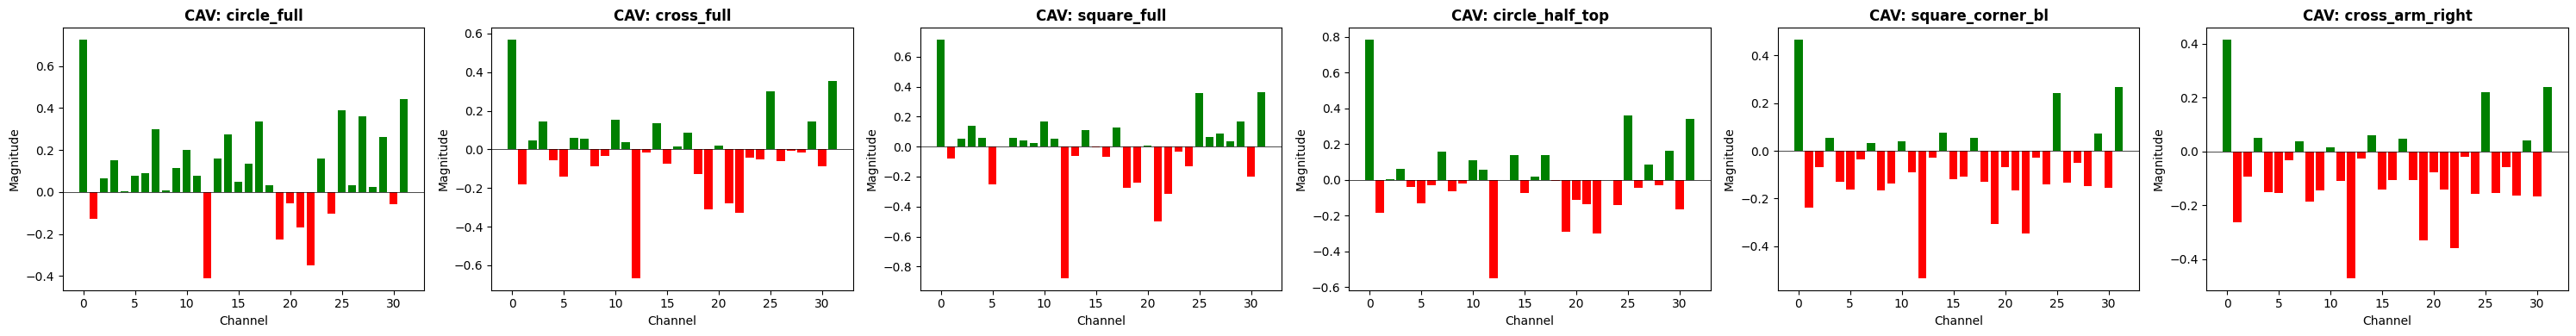

circle_full: norm=1.6634, emblem=(17.8874, 0.0000)
cross_full: norm=1.0624, emblem=(1.0610, 0.0000)
square_full: norm=1.0956, emblem=(1.0639, 0.0000)
circle_half_top: norm=1.5153, emblem=(0.9009, 0.0000)
square_corner_bl: norm=0.9959, emblem=(0.9659, 0.0000)
cross_arm_right: norm=0.9800, emblem=(0.9557, 0.0000)

Cosine similarities between CAV directions:
  circle_full vs cross_full: 0.4652
  circle_full vs square_full: 0.4288
  circle_full vs circle_half_top: 0.7142
  circle_full vs square_corner_bl: 0.4255
  circle_full vs cross_arm_right: 0.4245
  cross_full vs square_full: 0.9931
  cross_full vs circle_half_top: 0.8536
  cross_full vs square_corner_bl: 0.9928
  cross_full vs cross_arm_right: 0.9911
  square_full vs circle_half_top: 0.8277
  square_full vs square_corner_bl: 0.9968
  square_full vs cross_arm_right: 0.9962
  circle_half_top vs square_corner_bl: 0.8264
  circle_half_top vs cross_arm_right: 0.8262
  square_corner_bl vs cross_arm_right: 0.9998


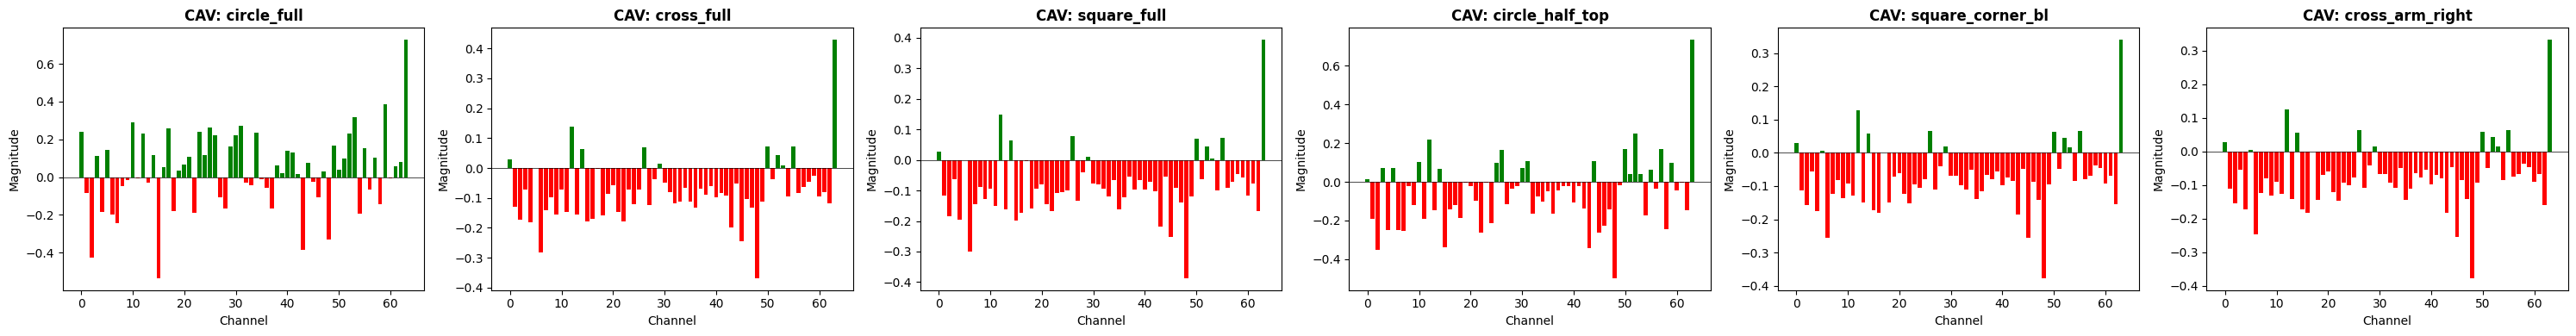

In [10]:
for x in [0, 1, 2]:
    concept_names = local_explainer.concepts
    layer_name = local_explainer.layers[x]

    
    cavs = {}
    for cn in concept_names:
        cav = local_explainer.getCAVs(layer_name, cn)
        cavs[cn] = cav.direction
        print(f'{cn}: norm={cav.direction.norm():.4f}, '
            f'emblem=({cav.concept_emblem[0]:.4f}, {cav.concept_emblem[1]:.4f})')

    
    print('\nCosine similarities between CAV directions:')
    for a, b in combinations(concept_names, 2):
        cos = F.cosine_similarity(
            cavs[a].unsqueeze(0), cavs[b].unsqueeze(0)
        ).item()
        print(f'  {a} vs {b}: {cos:.4f}')

    
    fig, axes = plt.subplots(1, len(concept_names), figsize=(5 * len(concept_names), 4))
    for ax, name in zip(axes, concept_names):
        d = cavs[name].cpu().numpy()
        ax.bar(range(len(d)), d, color=['green' if v > 0 else 'red' for v in d])
        ax.set_title(f'CAV: {name}', fontweight='bold')
        ax.set_xlabel('Channel')
        ax.set_ylabel('Magnitude')
        ax.axhline(0, color='black', linewidth=0.5)
    plt.tight_layout()
    plt.show()

## Sense Cercles


Model: FlexNet_CircleMediumSmall
    Image     Class name Confidence
00120.png Circle present       0.00


Layers: 100%|██████████| 3/3 [00:02<00:00,  1.36it/s]


circle_full @ conv_layers.0: {0: 0.13566303253173828, 1: 0.05734298378229141}
circle_full @ conv_layers.1: {0: 0.0996239185333252, 1: 0.028259161859750748}
circle_full @ conv_layers.2: {0: 0.019213033840060234, 1: 0.2590489983558655}
cross_full @ conv_layers.0: {0: 0.03550274670124054, 1: 0.01667143777012825}
cross_full @ conv_layers.1: {0: 0.08365985006093979, 1: 0.0305622648447752}
cross_full @ conv_layers.2: {0: 0.06875797361135483, 1: 0.5414072275161743}
square_full @ conv_layers.0: {0: 0.058006953448057175, 1: 0.05459868907928467}
square_full @ conv_layers.1: {0: 0.07991176098585129, 1: 0.028942538425326347}
square_full @ conv_layers.2: {0: 0.05130326747894287, 1: 0.37528103590011597}
circle_half_top @ conv_layers.0: {0: 0.05251619592308998, 1: 0.015284987166523933}
circle_half_top @ conv_layers.1: {0: 0.06872431933879852, 1: 0.011321384459733963}
circle_half_top @ conv_layers.2: {0: 0.07936957478523254, 1: 0.6117327213287354}
square_corner_bl @ conv_layers.0: {0: 0.02008439600467

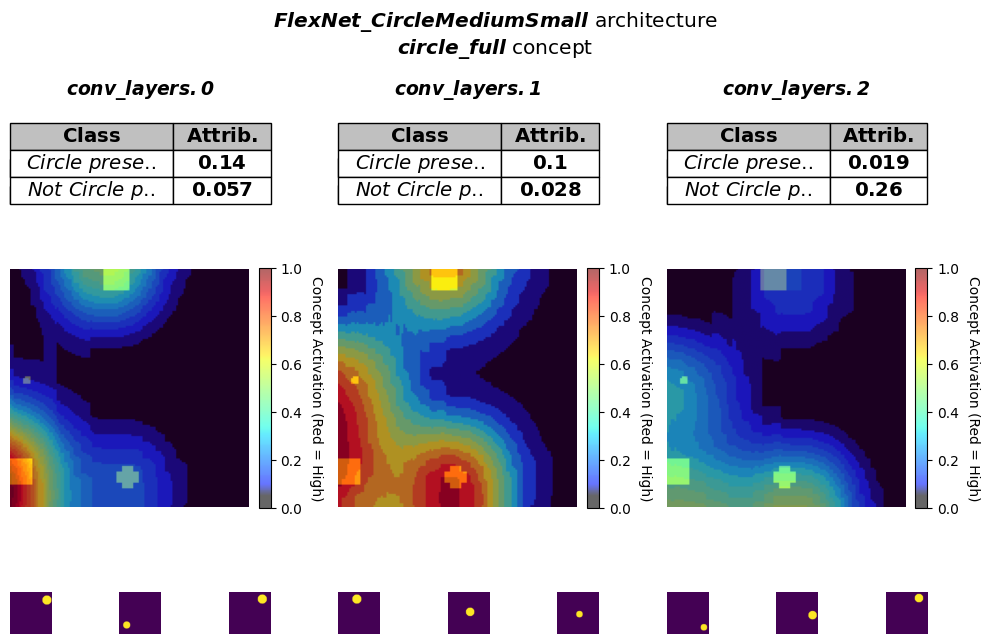

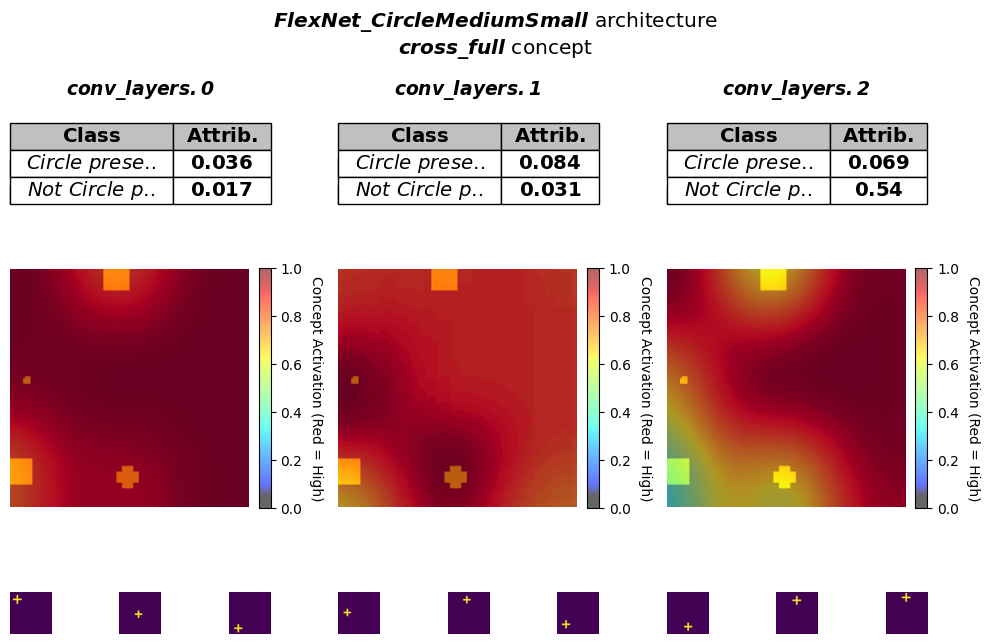

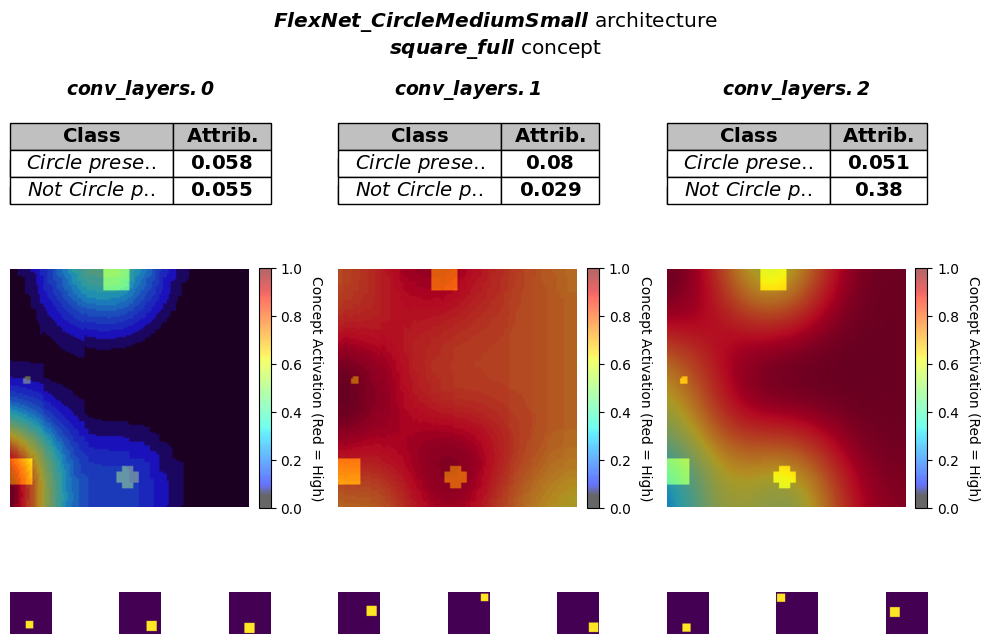

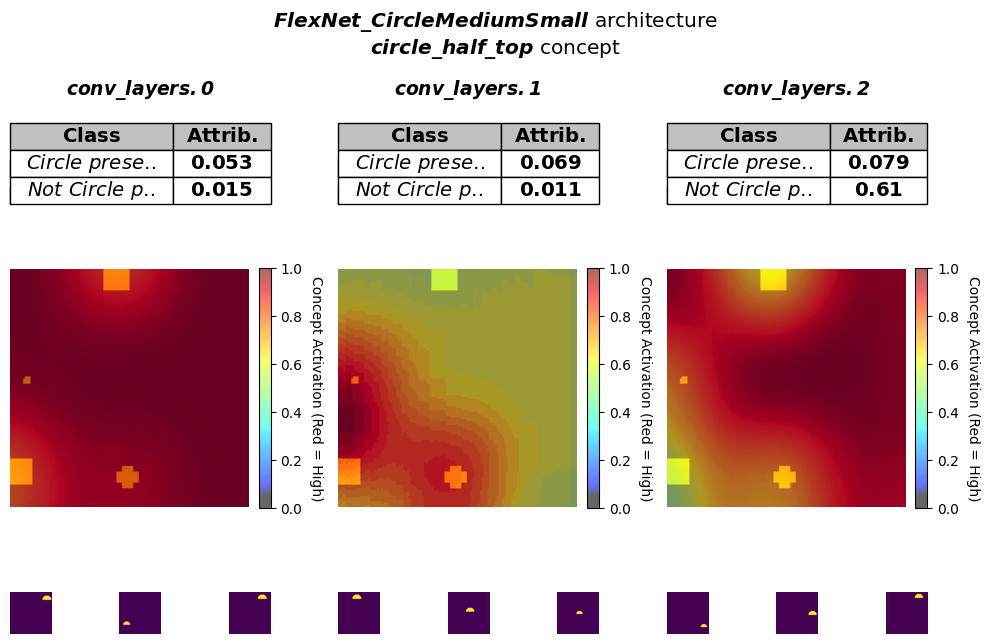

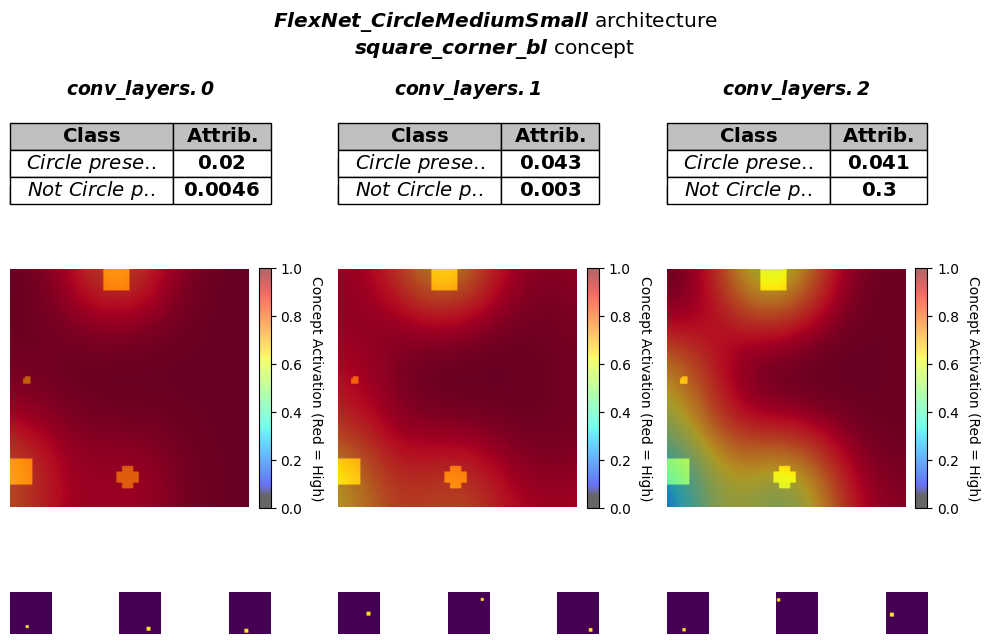

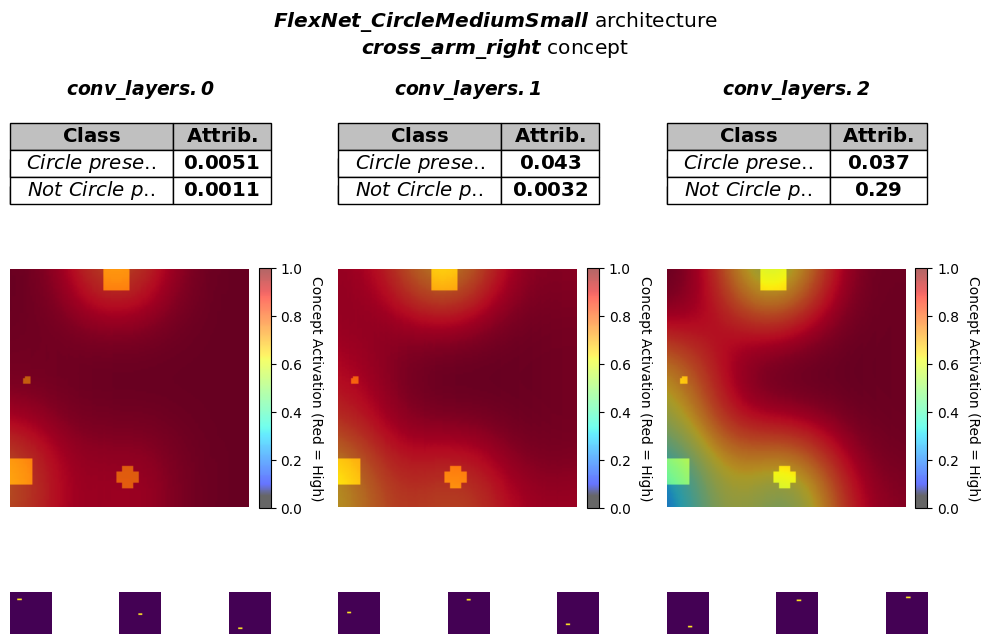

In [11]:
local_explainer2 = LocalVisualTCAV(
    test_image_filename=f'{img_without[0]:05d}.png',
    m_steps=50,
    model=vtcav_model,
    concept_images_dir=CONCEPTS_DIR,
    test_images_dir=TEST_IMAGES_DIR,
    random_images_folder='random_pool_4',
    cav_method='classifier',
    device=DEVICE,
)

local_explainer2.setConcepts(CONCEPTS)
local_explainer2.setLayers(['conv_layers.0', 'conv_layers.1', 'conv_layers.2'])

predictions2 = local_explainer2.predict(no_sort=True)
predictions2.info()

local_explainer2.explain(cache_cav=False, cache_random=False)

for concept_name in local_explainer2.concepts:
    for layer_name in local_explainer2.layers:
        cl = local_explainer2.computations[layer_name][concept_name]
        attribs = {k: v.item() if isinstance(v, torch.Tensor) else v
                   for k, v in cl.attributions.items()}
        print(f'{concept_name} @ {layer_name}: {attribs}')

local_explainer2.plot()

## Global Explanation

In [12]:
import shutil

# Select 200 images per grup as stated in the paper
circle_indices, no_circle_indices = [], []
for r in rows:
    idx, c = int(r['']), int(r['c'])
    if c > 0 and len(circle_indices) < 200:
        circle_indices.append(idx)
    elif c == 0 and len(no_circle_indices) < 200:
        no_circle_indices.append(idx)


global_test_dir = PROJECT_ROOT / 'data' / 'aixi_shape' / 'val_global_test'
for group_name, indices in [('circle_present', circle_indices), ('circle_absent', no_circle_indices)]:
    group_dir = global_test_dir / group_name
    group_dir.mkdir(parents=True, exist_ok=True)
    for idx in indices:
        src = val_dir / f'{idx:05d}.png'
        dst = group_dir / f'{idx:05d}.png'
        if not dst.exists():
            shutil.copy2(src, dst)

print(f'Circle present: {len(circle_indices)} images')
print(f'Circle absent:  {len(no_circle_indices)} images')
print(f'Test dir: {global_test_dir}')

Circle present: 200 images
Circle absent:  200 images
Test dir: /home/dlc/VisualTCAV/data/aixi_shape/val_global_test


In [13]:
global_circle = GlobalVisualTCAV(
    target_class='Circle present',
    test_images_folder='circle_present',
    m_steps=80,
    model=vtcav_model,
    concept_images_dir=CONCEPTS_DIR,
    test_images_dir=str(global_test_dir),
    random_images_folder='random_pool_4',
    cav_method=METHOD_CAV,
    device=DEVICE,
)

global_circle.setConcepts(CONCEPTS)
global_circle.setLayers(['conv_layers.0', 'conv_layers.1', 'conv_layers.2'])

print('Running global explanation - Circle Present...')
global_circle.explain(cache_cav=False, cache_random=False)

Running global explanation - Circle Present...


Layers: 100%|██████████| 3/3 [00:09<00:00,  3.23s/it]


In [14]:
global_circle.statsInfo()


Model: FlexNet_CircleMediumSmall | Class: Circle present | Folder: circle_present
         Concept         Layer        Attrib. mean    Attrib. 95.45% CI
     circle_full conv_layers.0      0.185 ± 0.0243       [0.182, 0.189]
                 conv_layers.1      0.184 ± 0.0167       [0.182, 0.186]
                 conv_layers.2     0.0755 ± 0.0132     [0.0736, 0.0774]
      cross_full conv_layers.0     0.0637 ± 0.0124     [0.0619, 0.0654]
                 conv_layers.1     0.0489 ± 0.0134      [0.047, 0.0508]
                 conv_layers.2  0.000966 ± 0.00151  [0.000752, 0.00118]
     square_full conv_layers.0     0.0832 ± 0.0138     [0.0812, 0.0851]
                 conv_layers.1     0.0473 ± 0.0133     [0.0454, 0.0492]
                 conv_layers.2   0.00073 ± 0.00101 [0.000587, 0.000873]
 circle_half_top conv_layers.0     0.0838 ± 0.0116     [0.0822, 0.0855]
                 conv_layers.1     0.0525 ± 0.0113     [0.0509, 0.0541]
                 conv_layers.2   0.00254 ± 0.00309   

In [15]:
global_no_circle = GlobalVisualTCAV(
    target_class='Circle absent',  
    test_images_folder='circle_absent',
    m_steps=80,
    model=vtcav_model,
    concept_images_dir=CONCEPTS_DIR,
    test_images_dir=str(global_test_dir),
    random_images_folder='random_pool_4',
    cav_method=METHOD_CAV,
    device=DEVICE,
)

global_no_circle.setConcepts(CONCEPTS)
global_no_circle.setLayers(['conv_layers.0', 'conv_layers.1','conv_layers.2'])

print('Running global explanation - Circle Absent...')
global_no_circle.explain(cache_cav=False, cache_random=False)

Running global explanation - Circle Absent...


Layers: 100%|██████████| 3/3 [00:09<00:00,  3.21s/it]


In [16]:
global_no_circle.statsInfo()


Model: FlexNet_CircleMediumSmall | Class: Circle absent | Folder: circle_absent
         Concept         Layer      Attrib. mean  Attrib. 95.45% CI
     circle_full conv_layers.0    0.137 ± 0.0759     [0.127, 0.148]
                 conv_layers.1   0.0963 ± 0.0684    [0.0866, 0.106]
                 conv_layers.2   0.0217 ± 0.0289   [0.0176, 0.0258]
      cross_full conv_layers.0   0.0288 ± 0.0221   [0.0256, 0.0319]
                 conv_layers.1   0.0691 ± 0.0565   [0.0611, 0.0771]
                 conv_layers.2   0.0488 ± 0.0447   [0.0425, 0.0551]
     square_full conv_layers.0   0.0707 ± 0.0392   [0.0651, 0.0762]
                 conv_layers.1   0.0671 ± 0.0521   [0.0597, 0.0745]
                 conv_layers.2   0.0473 ± 0.0466   [0.0407, 0.0539]
 circle_half_top conv_layers.0    0.0489 ± 0.038   [0.0436, 0.0543]
                 conv_layers.1   0.0557 ± 0.0579   [0.0475, 0.0639]
                 conv_layers.2   0.0456 ± 0.0421   [0.0396, 0.0515]
square_corner_bl conv_layers.0   0.

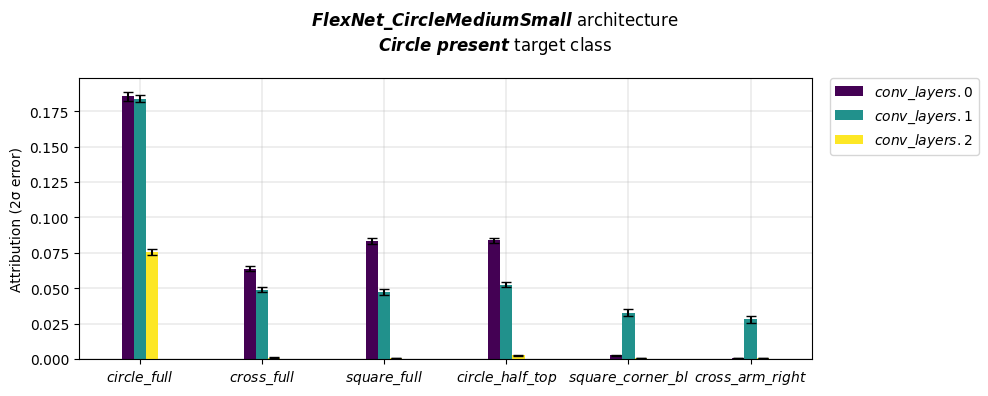

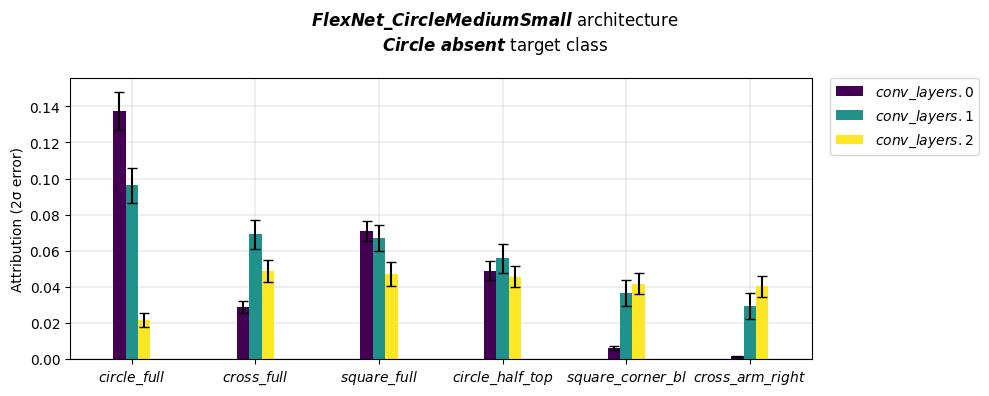

In [17]:
global_circle.plot()
global_no_circle.plot()

In [18]:
# --- Retrieve all conv layer names from the model ---
all_conv_layers = [name for name in vtcav_model.getLayerNames() if name.startswith('conv_layers.')]
print(f'Conv layers found: {all_conv_layers}\n')

local_clf = LocalVisualTCAV(
    test_image_filename=f'{img_with[0]:05d}.png',
    m_steps=50,
    model=vtcav_model,
    concept_images_dir=CONCEPTS_DIR,
    test_images_dir=TEST_IMAGES_DIR,
    random_images_folder='random_pool_4',
    cav_method='classifier',
    device=DEVICE,
)

local_clf.setConcepts(CONCEPTS)
local_clf.setLayers(all_conv_layers)

predictions_clf = local_clf.predict(no_sort=True)
local_clf.explain(cache_cav=False, cache_random=False)

# --- Print classifier-based CAVs per layer ---
print('=== Classifier-based CAVs ===')
for layer_name in all_conv_layers:
    print(f'\n--- {layer_name} ---')
    for concept_name in local_clf.concepts:
        cav = local_clf.getCAVs(layer_name, concept_name)
        attribs = local_clf.computations[layer_name][concept_name].attributions
        attribs = {k: v.item() if isinstance(v, torch.Tensor) else v for k, v in attribs.items()}
        print(f'  {concept_name}: accuracy={cav.accuracy:.3f}, attribs={attribs}')

# --- Print centroid-based CAVs per layer (from earlier explainer) ---
print('\n=== Centroid-based CAVs (from section 6) ===')
for layer_name in local_explainer.layers:
    print(f'\n--- {layer_name} ---')
    for concept_name in local_explainer.concepts:
        attribs = local_explainer.computations[layer_name][concept_name].attributions
        attribs = {k: v.item() if isinstance(v, torch.Tensor) else v for k, v in attribs.items()}
        print(f'  {concept_name}: attribs={attribs}')

Conv layers found: ['conv_layers.0', 'conv_layers.0.0', 'conv_layers.1', 'conv_layers.1.0', 'conv_layers.2', 'conv_layers.2.0']



Layers: 100%|██████████| 6/6 [00:04<00:00,  1.30it/s]

=== Classifier-based CAVs ===

--- conv_layers.0 ---
  circle_full: accuracy=0.995, attribs={0: 0.19735892117023468, 1: 0.0654791072010994}
  cross_full: accuracy=1.000, attribs={0: 0.07184197753667831, 1: 0.021565278992056847}
  square_full: accuracy=0.995, attribs={0: 0.09250698983669281, 1: 0.058183662593364716}
  circle_half_top: accuracy=0.995, attribs={0: 0.09298162907361984, 1: 0.020598571747541428}
  square_corner_bl: accuracy=1.000, attribs={0: 0.0030677588656544685, 1: 0.0013386438367888331}
  cross_arm_right: accuracy=1.000, attribs={0: 0.0007784029003232718, 1: 0.0003288628358859569}

--- conv_layers.0.0 ---
  circle_full: accuracy=0.975, attribs={0: 7.090541487286828e-08, 1: 9.879766338372065e-09}
  cross_full: accuracy=0.985, attribs={0: 0.0, 1: 0.0}
  square_full: accuracy=0.970, attribs={0: 3.9200668311423215e-07, 1: 5.5919944230709007e-08}
  circle_half_top: accuracy=0.980, attribs={0: 0.0, 1: 0.0}
  square_corner_bl: accuracy=0.990, attribs={0: 0.0, 1: 0.0}
  cross_ar

In [19]:
# --- Compare centroid vs classifier CAV directions across all shared layers ---
shared_layers = [l for l in all_conv_layers if l in local_explainer.layers]

print('Cosine similarity between centroid and classifier CAV directions:')
for layer_name in shared_layers:
    print(f'\n--- {layer_name} ---')
    for cn in concept_names:
        d_centroid = local_explainer.getCAVs(layer_name, cn).direction   # shape: [C]
        d_classifier = local_clf.getCAVs(layer_name, cn).direction       # shape: [C]
        cos = F.cosine_similarity(
            d_centroid.unsqueeze(0),   # [1, C]
            d_classifier.unsqueeze(0)  # [1, C]
        ).item()
        print(f'  {cn}: {cos:.4f}')

Cosine similarity between centroid and classifier CAV directions:

--- conv_layers.0 ---
  circle_full: 1.0000
  cross_full: 1.0000
  square_full: 1.0000
  circle_half_top: 1.0000
  square_corner_bl: 1.0000
  cross_arm_right: 1.0000

--- conv_layers.1 ---
  circle_full: 1.0000
  cross_full: 1.0000
  square_full: 1.0000
  circle_half_top: 1.0000
  square_corner_bl: 1.0000
  cross_arm_right: 1.0000

--- conv_layers.2 ---
  circle_full: 1.0000
  cross_full: 1.0000
  square_full: 1.0000
  circle_half_top: 1.0000
  square_corner_bl: 1.0000
  cross_arm_right: 1.0000


In [21]:

# ══════════════════════════════════════════════════════════════
# Spatial Localization Evaluation — evaluation_metrics.py
# ══════════════════════════════════════════════════════════════
# CONFIG: set these two to choose what to evaluate
CONCEPT_NAME   = "circle_full"   # concept whose map to evaluate
SHAPE_TYPE     = "circle"        # "cross" | "square" | "circle"  (GT channel)

LAYERS_TO_EVAL = ['conv_layers.0', 'conv_layers.1', 'conv_layers.2']
N_EVAL         = 300             # max positive / negative images
# ══════════════════════════════════════════════════════════════

import sys, os, csv, importlib
import numpy as np
import torch
import torch.nn.functional as F
from pathlib import Path
from PIL import Image
from collections import defaultdict
from captum.attr import LayerActivation

# Ensure VisualTCAV root (parent of notebooks_circles/) is on the path
_here = Path(os.path.abspath(''))
_vtcav_root = _here.parent if _here.name == 'notebooks_circles' else _here
if str(_vtcav_root) not in sys.path:
    sys.path.insert(0, str(_vtcav_root))

import evaluation_metrics as em
importlib.reload(em)   # pick up any edits made since kernel start

# Paths (relative to VisualTCAV root, matching rest of notebook)
GT_DIR     = _vtcav_root / 'data' / 'aixi_shape' / 'val' / 'gt'
IMAGES_DIR = _vtcav_root / 'data' / 'aixi_shape' / 'val'
VAL_CSV    = _vtcav_root / 'data' / 'aixi_shape' / 'val' / 'dades.csv'

GT_CHANNEL = {"cross": 0, "square": 1, "circle": 2}[SHAPE_TYPE]
CSV_COL    = {"cross": "cr", "square": "s", "circle": "c"}[SHAPE_TYPE]

# ── 1. Load positive / negative indices from CSV ─────────────
with open(VAL_CSV) as f:
    _rows = list(csv.DictReader(f, delimiter=';'))

pos_idx, neg_idx = [], []
for r in _rows:
    idx = int(r[''])
    if int(r[CSV_COL]) > 0 and len(pos_idx) < N_EVAL:
        pos_idx.append(idx)
    elif int(r[CSV_COL]) == 0 and len(neg_idx) < N_EVAL:
        neg_idx.append(idx)

print(f"Concept: {CONCEPT_NAME}  |  GT shape: {SHAPE_TYPE}")
print(f"Positive images: {len(pos_idx)}   Negative images: {len(neg_idx)}")

# ── 2. Build evaluation explainer ────────────────────────────
eval_exp = LocalVisualTCAV(
    test_image_filename=f'{pos_idx[0]:05d}.png',
    m_steps=50,
    model=vtcav_model,
    concept_images_dir=CONCEPTS_DIR,
    test_images_dir=str(IMAGES_DIR),
    random_images_folder='random_pool_4',
    cav_method=METHOD_CAV,
    device=DEVICE,
)
eval_exp.setConcepts(CONCEPTS)
eval_exp.setLayers(LAYERS_TO_EVAL)
_ = eval_exp.predict(no_sort=True)
eval_exp.explain(cache_cav=True, cache_random=True)


# ── 3. Helpers ───────────────────────────────────────────────
def _load_image(img_path):
    mw   = eval_exp.model.model_wrapper
    h, w, c = mw.get_image_shape()
    mode = 'L' if c == 1 else 'RGB'
    img  = Image.open(img_path).convert(mode).resize((w, h), Image.BILINEAR)
    arr  = np.array([np.array(img)])
    if c == 1 and arr.ndim == 3:
        arr = arr[..., np.newaxis]
    t = eval_exp.model.preprocessing_function(arr)
    if not isinstance(t, torch.Tensor):
        t = torch.tensor(t, dtype=torch.float32)
    if t.ndim == 3: t = t.unsqueeze(0)
    if t.ndim == 4 and t.shape[-1] in (1, 3): t = t.permute(0, 3, 1, 2)
    return t.to(DEVICE)


def _load_gt(idx):
    gt_img = np.array(Image.open(GT_DIR / f'{idx:05d}.png').convert('RGB'))
    return (gt_img[:, :, GT_CHANNEL] > 0).astype(np.float32)


def _downsample_gt(mask, h, w):
    t = torch.tensor(mask, dtype=torch.float32)
    d = F.interpolate(t[None, None], size=(h, w), mode='bilinear', align_corners=False).squeeze()
    return (d > 0.5).float()


# ── 4. Per-layer evaluation ───────────────────────────────────
all_rows = []

for layer_name in LAYERS_TO_EVAL:
    print(f"  {CONCEPT_NAME} @ {layer_name} ...", end=' ', flush=True)

    random_fmaps = eval_exp._compute_random_activations(cache=True, layer_name=layer_name)
    if not isinstance(random_fmaps, torch.Tensor):
        random_fmaps = torch.tensor(random_fmaps, dtype=torch.float32, device=DEVICE)
    cl        = eval_exp._compute_cavs(cache=True, concept_name=CONCEPT_NAME,
                                       layer_name=layer_name, random_acts=random_fmaps)
    direction = cl.cav.direction
    emblem    = cl.cav.concept_emblem

    layer_mod = eval_exp.model.model_wrapper.get_layer_module(layer_name)
    layer_act = LayerActivation(eval_exp.model.model_wrapper.model, layer_mod)

    metrics = defaultdict(list)

    for idx in pos_idx:
        with torch.no_grad():
            fmaps = layer_act.attribute(_load_image(IMAGES_DIR / f'{idx:05d}.png'))[0]

        cmap = eval_exp._compute_concept_map(fmaps, direction, emblem)
        gt   = _downsample_gt(_load_gt(idx), *cmap.shape).to(DEVICE)

        loc  = em.evaluate_concept_map_localization(cmap, gt)
        dist = em.evaluate_distribution_metrics(cmap, gt)

        metrics['siou'].append(loc.soft_iou)
        metrics['bmse'].append(loc.balanced_mse)
        metrics['auc'].append(loc.spatial_auc)
        metrics['emd'].append(dist.emd)
        metrics['min'].append(dist.sim_min)

    neg_acts = []
    for idx in neg_idx:
        with torch.no_grad():
            fmaps_n = layer_act.attribute(_load_image(IMAGES_DIR / f'{idx:05d}.png'))[0]
        cmap_n = eval_exp._compute_concept_map(fmaps_n, direction, emblem)
        neg_acts.append(cmap_n.mean().item())

    all_rows.append(dict(
        layer=layer_name, n=len(pos_idx),
        siou=np.mean(metrics['siou']), siou_s=np.std(metrics['siou']),
        bmse=np.mean(metrics['bmse']), bmse_s=np.std(metrics['bmse']),
        emd =np.mean(metrics['emd']),  emd_s =np.std(metrics['emd']),
        sim =np.mean(metrics['min']),  sim_s =np.std(metrics['min']),
        auc =np.mean(metrics['auc']),  auc_s =np.std(metrics['auc']),
        neg =np.mean(neg_acts),
    ))
    r = all_rows[-1]
    print(f"IoU={r['siou']:.3f}  AUC={r['auc']:.3f}")

# ── 5. Results table ──────────────────────────────────────────
print(f"\nConcept: {CONCEPT_NAME}  |  GT channel: {SHAPE_TYPE}\n")
print(f"{'Layer':<20} {'N':>4} {'Soft IoU ↑':>13} {'Bal.MSE ↓':>13} {'EMD ↓':>12} {'MIN ↑':>12} {'AUC ↑':>11} {'Neg.Act ↓':>10}")
print("-" * 99)
for r in all_rows:
    print(
        f"{r['layer']:<20} {r['n']:>4} "
        f"{r['siou']:>6.4f}±{r['siou_s']:<5.4f} "
        f"{r['bmse']:>6.4f}±{r['bmse_s']:<5.4f} "
        f"{r['emd']:>5.4f}±{r['emd_s']:<5.4f} "
        f"{r['sim']:>5.4f}±{r['sim_s']:<5.4f} "
        f"{r['auc']:>5.4f}±{r['auc_s']:<5.4f} "
        f"{r['neg']:>10.4f}"
    )
print("\nAUC baseline = 0.5 (chance). AUC = 1.0 = perfect spatial discrimination.")


Concept: circle_full  |  GT shape: circle
Positive images: 300   Negative images: 300


Layers: 100%|██████████| 3/3 [00:01<00:00,  2.68it/s]

  circle_full @ conv_layers.0 ... 

IoU=0.061  AUC=0.580
  circle_full @ conv_layers.1 ... IoU=0.072  AUC=0.739
  circle_full @ conv_layers.2 ... IoU=0.034  AUC=0.603

Concept: circle_full  |  GT channel: circle

Layer                   N    Soft IoU ↑     Bal.MSE ↓        EMD ↓        MIN ↑       AUC ↑  Neg.Act ↓
---------------------------------------------------------------------------------------------------
conv_layers.0         300 0.0605±0.0174 0.4414±0.0161 0.0001±0.0001 0.1034±0.0291 0.5796±0.0205     0.0051
conv_layers.1         300 0.0724±0.0282 0.3417±0.0599 0.0013±0.0003 0.0936±0.0400 0.7393±0.0847     0.0113
conv_layers.2         300 0.0335±0.0361 0.4264±0.0835 0.0057±0.0009 0.0421±0.0457 0.6028±0.1348     0.0082

AUC baseline = 0.5 (chance). AUC = 1.0 = perfect spatial discrimination.
